In [1]:
# ============================================================
# Experiment 1
# Classification Performance Evaluation of TPN
# Breast Cancer Wisconsin Dataset
# ============================================================

import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# ============================================================
# Load Dataset
# ============================================================

data = load_breast_cancer()

X = data.data
y = data.target

# ============================================================
# Proposed TPN Model
# ============================================================

class TPN(nn.Module):

    def __init__(self, input_dim):

        super().__init__()

        self.W = nn.Parameter(
            torch.randn(input_dim, 64) * 0.01
        )

        self.P = nn.Parameter(
            torch.randn(input_dim, 64) * 0.01
        )

        self.hidden_bias = nn.Parameter(
            torch.zeros(64)
        )

        self.output_layer = nn.Linear(
            64,
            1
        )

    def forward(self, x):

        mask = torch.sigmoid(self.P)

        effective_weight = self.W * mask

        hidden = torch.relu(
            torch.matmul(x, effective_weight)
            + self.hidden_bias
        )

        output = torch.sigmoid(
            self.output_layer(hidden)
        )

        return output


# ============================================================
# Cross Validation
# ============================================================

cv = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

results = []

# ============================================================
# Evaluate Models
# ============================================================

models = {
    "LR": LogisticRegression(max_iter=5000),

    "SVM": SVC(
        kernel="rbf",
        probability=True
    ),

    "RF": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),

    "MLP": MLPClassifier(
        hidden_layer_sizes=(64,),
        max_iter=500,
        random_state=42
    )
}

# ------------------------------------------------------------
# Traditional Models
# ------------------------------------------------------------

for model_name, model in models.items():

    accs = []
    precs = []
    recs = []
    f1s = []

    for train_idx, test_idx in cv.split(X, y):

        X_train = X[train_idx]
        X_test = X[test_idx]

        y_train = y[train_idx]
        y_test = y[test_idx]

        scaler = StandardScaler()

        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        model.fit(X_train, y_train)

        preds = model.predict(X_test)

        accs.append(
            accuracy_score(y_test, preds)
        )

        precs.append(
            precision_score(y_test, preds)
        )

        recs.append(
            recall_score(y_test, preds)
        )

        f1s.append(
            f1_score(y_test, preds)
        )

    results.append([
        model_name,
        np.mean(accs),
        np.mean(precs),
        np.mean(recs),
        np.mean(f1s)
    ])

# ------------------------------------------------------------
# TPN Evaluation
# ------------------------------------------------------------

accs = []
precs = []
recs = []
f1s = []

for train_idx, test_idx in cv.split(X, y):

    X_train = X[train_idx]
    X_test = X[test_idx]

    y_train = y[train_idx]
    y_test = y[test_idx]

    scaler = StandardScaler()

    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    X_train_tensor = torch.tensor(
        X_train,
        dtype=torch.float32
    )

    X_test_tensor = torch.tensor(
        X_test,
        dtype=torch.float32
    )

    y_train_tensor = torch.tensor(
        y_train.reshape(-1, 1),
        dtype=torch.float32
    )

    model = TPN(
        input_dim=X_train.shape[1]
    )

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=0.001
    )

    criterion = nn.BCELoss()

    # Training

    for epoch in range(100):

        optimizer.zero_grad()

        outputs = model(X_train_tensor)

        loss = criterion(
            outputs,
            y_train_tensor
        )

        loss.backward()

        optimizer.step()

    # Testing

    with torch.no_grad():

        preds = model(
            X_test_tensor
        )

        preds = (
            preds.numpy() > 0.5
        ).astype(int)

    accs.append(
        accuracy_score(y_test, preds)
    )

    precs.append(
        precision_score(y_test, preds)
    )

    recs.append(
        recall_score(y_test, preds)
    )

    f1s.append(
        f1_score(y_test, preds)
    )

results.append([
    "TPN",
    np.mean(accs),
    np.mean(precs),
    np.mean(recs),
    np.mean(f1s)
])

# ============================================================
# Results Table
# ============================================================

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

print("\nExperiment 1 Results\n")

print(
    results_df.round(4)
)

# ============================================================
# Save Results
# ============================================================

results_df.to_csv(
    "Experiment1_BreastCancer_TPN.csv",
    index=False
)

print(
    "\nResults saved as Experiment1_BreastCancer_TPN.csv"
)


Experiment 1 Results

  Model  Accuracy  Precision  Recall  F1 Score
1   SVM    0.9754     0.9784  0.9833    0.9805
3   MLP    0.9754     0.9790  0.9831    0.9806
0    LR    0.9754     0.9736  0.9888    0.9808
4   TPN    0.9614     0.9735  0.9664    0.9690
2    RF    0.9544     0.9605  0.9692    0.9641

Results saved as Experiment1_BreastCancer_TPN.csv


Experiment 2: Connectivity Reduction Analysis

In [2]:
# ============================================================
# Experiment 2
# Connectivity Reduction Analysis
# ============================================================

import numpy as np
import torch
import torch.nn as nn

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler

# ============================================================
# Dataset
# ============================================================

data = load_breast_cancer()

X = data.data
y = data.target

# ============================================================
# TPN Model
# ============================================================

class TPN(nn.Module):

    def __init__(self, input_dim):

        super().__init__()

        self.W = nn.Parameter(
            torch.randn(input_dim, 64) * 0.01
        )

        self.P = nn.Parameter(
            torch.randn(input_dim, 64) * 0.01
        )

        self.hidden_bias = nn.Parameter(
            torch.zeros(64)
        )

        self.output_layer = nn.Linear(
            64,
            1
        )

    def forward(self, x):

        mask = torch.sigmoid(self.P)

        effective_weight = self.W * mask

        hidden = torch.relu(
            torch.matmul(x, effective_weight)
            + self.hidden_bias
        )

        output = torch.sigmoid(
            self.output_layer(hidden)
        )

        return output

# ============================================================
# Cross Validation
# ============================================================

cv = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

active_list = []
sparsity_list = []
reduction_list = []

# ============================================================
# Run Experiment
# ============================================================

for fold, (train_idx, test_idx) in enumerate(cv.split(X, y), 1):

    X_train = X[train_idx]
    y_train = y[train_idx]

    scaler = StandardScaler()

    X_train = scaler.fit_transform(X_train)

    X_train_tensor = torch.tensor(
        X_train,
        dtype=torch.float32
    )

    y_train_tensor = torch.tensor(
        y_train.reshape(-1, 1),
        dtype=torch.float32
    )

    model = TPN(
        input_dim=X_train.shape[1]
    )

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=0.001
    )

    criterion = nn.BCELoss()

    # Training

    for epoch in range(100):

        optimizer.zero_grad()

        outputs = model(X_train_tensor)

        loss = criterion(
            outputs,
            y_train_tensor
        )

        loss.backward()

        optimizer.step()

    # =====================================================
    # Connectivity Analysis
    # =====================================================

    with torch.no_grad():

        mask = torch.sigmoid(model.P)

        total_connections = mask.numel()

        active_connections = (
            mask > 0.5
        ).sum().item()

        sparsity = (
            1 -
            active_connections /
            total_connections
        )

        reduction = sparsity * 100

        active_list.append(
            active_connections
        )

        sparsity_list.append(
            sparsity
        )

        reduction_list.append(
            reduction
        )

# ============================================================
# Average Results
# ============================================================

avg_active = np.mean(active_list)
avg_sparsity = np.mean(sparsity_list)
avg_reduction = np.mean(reduction_list)

print("\n===================================")
print("Experiment 2 Results")
print("Connectivity Reduction Analysis")
print("===================================")

print(
    f"Total Connections : {total_connections}"
)

print(
    f"Average Active Connections : {avg_active:.2f}"
)

print(
    f"Average Sparsity : {avg_sparsity:.4f}"
)

print(
    f"Average Reduction (%) : {avg_reduction:.2f}"
)

# ============================================================
# Table for Paper
# ============================================================

import pandas as pd

results_df = pd.DataFrame({

    "Dataset":
        ["Breast Cancer"],

    "Total Connections":
        [total_connections],

    "Active Connections":
        [round(avg_active, 2)],

    "Sparsity":
        [round(avg_sparsity, 4)],

    "Reduction (%)":
        [round(avg_reduction, 2)]

})

print("\n")
print(results_df)

results_df.to_csv(
    "Experiment2_ConnectivityReduction.csv",
    index=False
)

print(
    "\nSaved: Experiment2_ConnectivityReduction.csv"
)


Experiment 2 Results
Connectivity Reduction Analysis
Total Connections : 1920
Average Active Connections : 1791.60
Average Sparsity : 0.0669
Average Reduction (%) : 6.69


         Dataset  Total Connections  Active Connections  Sparsity  \
0  Breast Cancer               1920              1791.6    0.0669   

   Reduction (%)  
0           6.69  

Saved: Experiment2_ConnectivityReduction.csv


PN-v2 (Sparse Topology Plasticity Network)

In [3]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ============================================================
# Dataset
# ============================================================

data = load_breast_cancer()

X = data.data
y = data.target

# ============================================================
# Sparse TPN-v2
# ============================================================

class SparseTPN(nn.Module):

    def __init__(self, input_dim):

        super().__init__()

        self.W = nn.Parameter(
            torch.randn(input_dim, 64) * 0.01
        )

        self.P = nn.Parameter(
            torch.randn(input_dim, 64) * 0.01
        )

        self.hidden_bias = nn.Parameter(
            torch.zeros(64)
        )

        self.output_layer = nn.Linear(
            64,
            1
        )

    def forward(self, x):

        mask = torch.sigmoid(self.P)

        effective_weight = self.W * mask

        hidden = torch.relu(
            torch.matmul(x, effective_weight)
            + self.hidden_bias
        )

        output = torch.sigmoid(
            self.output_layer(hidden)
        )

        return output, mask

# ============================================================
# Parameters
# ============================================================

LAMBDA_SPARSE = 0.01

cv = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

accs = []
precs = []
recs = []
f1s = []

active_connections_all = []
reduction_all = []

# ============================================================
# Cross Validation
# ============================================================

for train_idx, test_idx in cv.split(X, y):

    X_train = X[train_idx]
    X_test = X[test_idx]

    y_train = y[train_idx]
    y_test = y[test_idx]

    scaler = StandardScaler()

    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    X_train_tensor = torch.tensor(
        X_train,
        dtype=torch.float32
    )

    X_test_tensor = torch.tensor(
        X_test,
        dtype=torch.float32
    )

    y_train_tensor = torch.tensor(
        y_train.reshape(-1,1),
        dtype=torch.float32
    )

    model = SparseTPN(
        input_dim=X_train.shape[1]
    )

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=0.001
    )

    criterion = nn.BCELoss()

    # ========================================================
    # Training
    # ========================================================

    for epoch in range(100):

        optimizer.zero_grad()

        outputs, mask = model(
            X_train_tensor
        )

        classification_loss = criterion(
            outputs,
            y_train_tensor
        )

        sparsity_loss = mask.mean()

        loss = (
            classification_loss
            +
            LAMBDA_SPARSE * sparsity_loss
        )

        loss.backward()

        optimizer.step()

    # ========================================================
    # Prediction
    # ========================================================

    with torch.no_grad():

        outputs, mask = model(
            X_test_tensor
        )

        preds = (
            outputs.numpy() > 0.5
        ).astype(int)

    accs.append(
        accuracy_score(y_test, preds)
    )

    precs.append(
        precision_score(y_test, preds)
    )

    recs.append(
        recall_score(y_test, preds)
    )

    f1s.append(
        f1_score(y_test, preds)
    )

    # ========================================================
    # Connectivity Analysis
    # ========================================================

    with torch.no_grad():

        total_connections = mask.numel()

        active_connections = (
            mask > 0.5
        ).sum().item()

        reduction = (
            (total_connections - active_connections)
            / total_connections
        ) * 100

        active_connections_all.append(
            active_connections
        )

        reduction_all.append(
            reduction
        )

# ============================================================
# Final Results
# ============================================================

results = pd.DataFrame({

    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "Active Connections",
        "Reduction (%)"
    ],

    "Value": [

        np.mean(accs),

        np.mean(precs),

        np.mean(recs),

        np.mean(f1s),

        np.mean(active_connections_all),

        np.mean(reduction_all)
    ]
})

print("\nSparse TPN-v2 Results\n")
print(results.round(4))

results.to_csv(
    "Sparse_TPN_v2_Results.csv",
    index=False
)

print(
    "\nSaved: Sparse_TPN_v2_Results.csv"
)


Sparse TPN-v2 Results

               Metric      Value
0            Accuracy     0.9632
1           Precision     0.9736
2              Recall     0.9691
3            F1 Score     0.9705
4  Active Connections  1693.6000
5       Reduction (%)    11.7917

Saved: Sparse_TPN_v2_Results.csv


Sparse_TPN_v2B

In [7]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ============================================================
# Dataset
# ============================================================

data = load_breast_cancer()

X = data.data
y = data.target

# ============================================================
# Sparse TPN-v2
# ============================================================

class SparseTPN(nn.Module):

    def __init__(self, input_dim):

        super().__init__()

        self.W = nn.Parameter(
            torch.randn(input_dim, 64) * 0.01
        )

        self.P = nn.Parameter(
            torch.randn(input_dim, 64) * 0.01
        )

        self.hidden_bias = nn.Parameter(
            torch.zeros(64)
        )

        self.output_layer = nn.Linear(
            64,
            1
        )

    def forward(self, x):

        mask = torch.sigmoid(self.P)

        effective_weight = self.W * mask

        hidden = torch.relu(
            torch.matmul(x, effective_weight)
            + self.hidden_bias
        )

        output = torch.sigmoid(
            self.output_layer(hidden)
        )

        return output, mask

# ============================================================
# Parameters
# ============================================================

LAMBDA_SPARSE = 0.05

cv = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

accs = []
precs = []
recs = []
f1s = []

active_connections_all = []
reduction_all = []

# ============================================================
# Cross Validation
# ============================================================

for train_idx, test_idx in cv.split(X, y):

    X_train = X[train_idx]
    X_test = X[test_idx]

    y_train = y[train_idx]
    y_test = y[test_idx]

    scaler = StandardScaler()

    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    X_train_tensor = torch.tensor(
        X_train,
        dtype=torch.float32
    )

    X_test_tensor = torch.tensor(
        X_test,
        dtype=torch.float32
    )

    y_train_tensor = torch.tensor(
        y_train.reshape(-1,1),
        dtype=torch.float32
    )

    model = SparseTPN(
        input_dim=X_train.shape[1]
    )

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=0.001
    )

    criterion = nn.BCELoss()

    # ========================================================
    # Training
    # ========================================================

    for epoch in range(100):

        optimizer.zero_grad()

        outputs, mask = model(
            X_train_tensor
        )

        classification_loss = criterion(
            outputs,
            y_train_tensor
        )

        sparsity_loss = mask.mean()

        loss = (
            classification_loss
            +
            LAMBDA_SPARSE * sparsity_loss
        )

        loss.backward()

        optimizer.step()

    # ========================================================
    # Prediction
    # ========================================================

    with torch.no_grad():

        outputs, mask = model(
            X_test_tensor
        )

        preds = (
            outputs.numpy() > 0.5
        ).astype(int)

    accs.append(
        accuracy_score(y_test, preds)
    )

    precs.append(
        precision_score(y_test, preds)
    )

    recs.append(
        recall_score(y_test, preds)
    )

    f1s.append(
        f1_score(y_test, preds)
    )

    # ========================================================
    # Connectivity Analysis
    # ========================================================

    with torch.no_grad():

        total_connections = mask.numel()

        active_connections = (
            mask > 0.5
        ).sum().item()

        reduction = (
            (total_connections - active_connections)
            / total_connections
        ) * 100

        active_connections_all.append(
            active_connections
        )

        reduction_all.append(
            reduction
        )

# ============================================================
# Final Results
# ============================================================

results = pd.DataFrame({

    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "Active Connections",
        "Reduction (%)"
    ],

    "Value": [

        np.mean(accs),

        np.mean(precs),

        np.mean(recs),

        np.mean(f1s),

        np.mean(active_connections_all),

        np.mean(reduction_all)
    ]
})

print("\nSparse TPN-v2B Results\n")
print(results.round(4))

results.to_csv(
    "Sparse_TPN_v2B_Results.csv",
    index=False
)

print(
    "\nSaved: Sparse_TPN_v2B_Results.csv"
)


Sparse TPN-v2B Results

               Metric      Value
0            Accuracy     0.9632
1           Precision     0.9763
2              Recall     0.9664
3            F1 Score     0.9704
4  Active Connections  1531.4000
5       Reduction (%)    20.2396

Saved: Sparse_TPN_v2B_Results.csv


TPN_V2C

In [8]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ============================================================
# Dataset
# ============================================================

data = load_breast_cancer()

X = data.data
y = data.target

# ============================================================
# Sparse TPN-v2
# ============================================================

class SparseTPN(nn.Module):

    def __init__(self, input_dim):

        super().__init__()

        self.W = nn.Parameter(
            torch.randn(input_dim, 64) * 0.01
        )

        self.P = nn.Parameter(
            torch.randn(input_dim, 64) * 0.01
        )

        self.hidden_bias = nn.Parameter(
            torch.zeros(64)
        )

        self.output_layer = nn.Linear(
            64,
            1
        )

    def forward(self, x):

        mask = torch.sigmoid(self.P)

        effective_weight = self.W * mask

        hidden = torch.relu(
            torch.matmul(x, effective_weight)
            + self.hidden_bias
        )

        output = torch.sigmoid(
            self.output_layer(hidden)
        )

        return output, mask

# ============================================================
# Parameters
# ============================================================

LAMBDA_SPARSE = 0.10

cv = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

accs = []
precs = []
recs = []
f1s = []

active_connections_all = []
reduction_all = []

# ============================================================
# Cross Validation
# ============================================================

for train_idx, test_idx in cv.split(X, y):

    X_train = X[train_idx]
    X_test = X[test_idx]

    y_train = y[train_idx]
    y_test = y[test_idx]

    scaler = StandardScaler()

    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    X_train_tensor = torch.tensor(
        X_train,
        dtype=torch.float32
    )

    X_test_tensor = torch.tensor(
        X_test,
        dtype=torch.float32
    )

    y_train_tensor = torch.tensor(
        y_train.reshape(-1,1),
        dtype=torch.float32
    )

    model = SparseTPN(
        input_dim=X_train.shape[1]
    )

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=0.001
    )

    criterion = nn.BCELoss()

    # ========================================================
    # Training
    # ========================================================

    for epoch in range(100):

        optimizer.zero_grad()

        outputs, mask = model(
            X_train_tensor
        )

        classification_loss = criterion(
            outputs,
            y_train_tensor
        )

        sparsity_loss = mask.mean()

        loss = (
            classification_loss
            +
            LAMBDA_SPARSE * sparsity_loss
        )

        loss.backward()

        optimizer.step()

    # ========================================================
    # Prediction
    # ========================================================

    with torch.no_grad():

        outputs, mask = model(
            X_test_tensor
        )

        preds = (
            outputs.numpy() > 0.5
        ).astype(int)

    accs.append(
        accuracy_score(y_test, preds)
    )

    precs.append(
        precision_score(y_test, preds)
    )

    recs.append(
        recall_score(y_test, preds)
    )

    f1s.append(
        f1_score(y_test, preds)
    )

    # ========================================================
    # Connectivity Analysis
    # ========================================================

    with torch.no_grad():

        total_connections = mask.numel()

        active_connections = (
            mask > 0.5
        ).sum().item()

        reduction = (
            (total_connections - active_connections)
            / total_connections
        ) * 100

        active_connections_all.append(
            active_connections
        )

        reduction_all.append(
            reduction
        )

# ============================================================
# Final Results
# ============================================================

results = pd.DataFrame({

    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "Active Connections",
        "Reduction (%)"
    ],

    "Value": [

        np.mean(accs),

        np.mean(precs),

        np.mean(recs),

        np.mean(f1s),

        np.mean(active_connections_all),

        np.mean(reduction_all)
    ]
})

print("\nSparse TPN-v2C Results\n")
print(results.round(4))

results.to_csv(
    "Sparse_TPN_v2C_Results.csv",
    index=False
)

print(
    "\nSaved: Sparse_TPN_v2C_Results.csv"
)


Sparse TPN-v2C Results

               Metric      Value
0            Accuracy     0.9596
1           Precision     0.9762
2              Recall     0.9608
3            F1 Score     0.9675
4  Active Connections  1344.9000
5       Reduction (%)    29.9531

Saved: Sparse_TPN_v2C_Results.csv


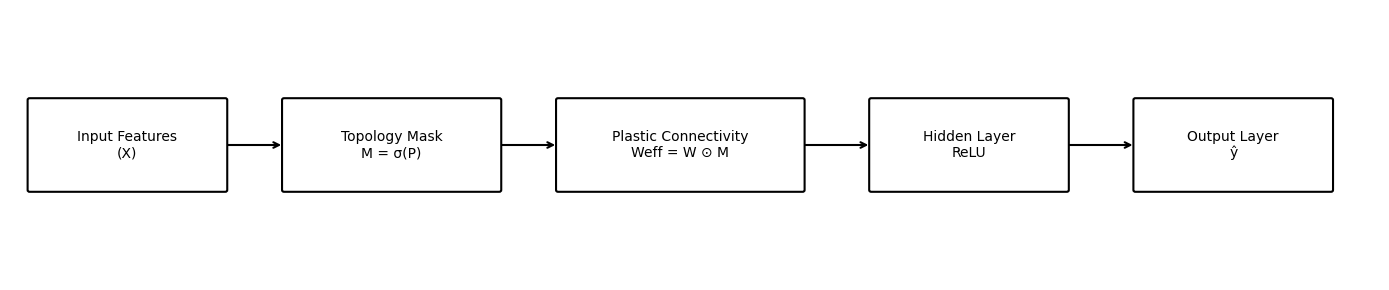

Saved:
Figure1_TPN_Architecture.png
Figure1_TPN_Architecture.pdf


In [9]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

# -------------------------------------------------
# Figure Setup
# -------------------------------------------------

fig, ax = plt.subplots(figsize=(14, 3))

ax.set_xlim(0, 14)
ax.set_ylim(0, 3)
ax.axis('off')

# -------------------------------------------------
# Function to Draw Blocks
# -------------------------------------------------

def draw_block(x, y, w, h, text):

    box = FancyBboxPatch(
        (x, y),
        w,
        h,
        boxstyle="round,pad=0.02",
        fill=False,
        linewidth=1.5
    )

    ax.add_patch(box)

    ax.text(
        x + w/2,
        y + h/2,
        text,
        ha='center',
        va='center',
        fontsize=10
    )

# -------------------------------------------------
# Blocks
# -------------------------------------------------

draw_block(
    0.2, 1.0,
    2.0, 1.0,
    "Input Features\n(X)"
)

draw_block(
    2.8, 1.0,
    2.2, 1.0,
    "Topology Mask\nM = σ(P)"
)

draw_block(
    5.6, 1.0,
    2.5, 1.0,
    "Plastic Connectivity\nWeff = W ⊙ M"
)

draw_block(
    8.8, 1.0,
    2.0, 1.0,
    "Hidden Layer\nReLU"
)

draw_block(
    11.5, 1.0,
    2.0, 1.0,
    "Output Layer\nŷ"
)

# -------------------------------------------------
# Arrows
# -------------------------------------------------

arrowprops = dict(
    arrowstyle="->",
    linewidth=1.5
)

ax.annotate("", xy=(2.8,1.5), xytext=(2.2,1.5), arrowprops=arrowprops)
ax.annotate("", xy=(5.6,1.5), xytext=(5.0,1.5), arrowprops=arrowprops)
ax.annotate("", xy=(8.8,1.5), xytext=(8.1,1.5), arrowprops=arrowprops)
ax.annotate("", xy=(11.5,1.5), xytext=(10.8,1.5), arrowprops=arrowprops)

# -------------------------------------------------
# Save Figure
# -------------------------------------------------

plt.tight_layout()

plt.savefig(
    "Figure1_TPN_Architecture.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    "Figure1_TPN_Architecture.pdf",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:")
print("Figure1_TPN_Architecture.png")
print("Figure1_TPN_Architecture.pdf")